# SegFormer-B0 Amodal Training with Full Augmentation (3000 images)

**Amodal Segmentation**: Multi-label approach where each mask (eyelid, iris, pupil) is predicted independently, allowing overlaps.

## Key Differences from Base Amodal Training
This notebook adds **comprehensive augmentation** for robustness:

### 1. RandomResizedCrop (Scale Augmentation)
- Scale: 80%-100% of original image
- Aspect ratio: 0.9-1.1
- Applied to both image and mask

### 2. Blur/Low-Quality Augmentation
- Blur (general blur)
- MotionBlur (camera shake)
- GaussianBlur (out-of-focus)
- ImageCompression (JPEG artifacts)
- Downscale (low resolution simulation)

## 3 Masks
| Channel | Name | Description |
|---------|------|-------------|
| 0 | eyelid | Full eyelid region (conjunctiva + visible iris/pupil) |
| 1 | iris | Full iris ellipse |
| 2 | pupil | Full pupil ellipse |

In [1]:
# ===== Cell 1: Imports =====
import json
import math
import random
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

# Albumentations for blur augmentation
import albumentations as A

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Albumentations: {A.__version__}")

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU
Albumentations: 2.0.8


In [2]:
# ===== Cell 2: Configuration =====
# Paths
PROJECT_ROOT = Path(".").resolve()
IMAGES_DIR = PROJECT_ROOT / "Images" / "images"
XML_EYELID = PROJECT_ROOT / "Images" / "eyelid_caruncle_seg_0-3000.xml"
XML_IRIS_PUPIL = PROJECT_ROOT / "Images" / "obb_iris_pupil_1-3000.xml"

# Changed output directory for blur augmentation experiment
OUTPUT_DIR = PROJECT_ROOT / "Ablation_SegFormerB0_Amodal_Blur"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = OUTPUT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data settings
IMAGE_SIZE = 512
NUM_CHANNELS = 3  # eyelid, iris, pupil (multi-label)
SEED = 42
VAL_RATIO = 0.2
MIN_IMAGE_ID = 0
MAX_IMAGE_ID = 2999  # ID 0-2999 = 3000 images

# Training settings
BATCH_SIZE = 8
NUM_EPOCHS = 1000
EARLY_STOP_PATIENCE = 20
LEARNING_RATE = 6e-5
WEIGHT_DECAY = 0.01
NUM_WORKERS = 0  # Windows compatibility
PIN_MEMORY = True

# Augmentation settings
ROTATION_DEGREE = 180  # Maximum rotation angle

# RandomResizedCrop settings
RANDOM_RESIZED_CROP_SCALE = (0.8, 1.0)  # Crop 80%-100% of original area
RANDOM_RESIZED_CROP_RATIO = (0.9, 1.1)  # Aspect ratio range
RANDOM_RESIZED_CROP_PROB = 0.5  # Probability of applying

# Blur/Low-quality augmentation settings
BLUR_AUGMENT_PROB = 0.5  # Probability of applying any blur augmentation

# Model settings
SEGFORMER_MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"

# Ellipse settings
ELLIPSE_NUM_POINTS = 100

# Loss settings (class imbalance handling)
CHANNEL_WEIGHTS = [1.0, 1.2, 3.0]  # eyelid, iris, pupil (sqrt scale)
TVERSKY_PARAMS = {
    'eyelid': {'alpha': 0.5, 'beta': 0.5},  # balanced
    'iris':   {'alpha': 0.4, 'beta': 0.6},  # slightly recall-focused
    'pupil':  {'alpha': 0.3, 'beta': 0.7},  # recall-focused (small region)
}
CONSTRAINT_WEIGHT = 0.1  # physical constraint weight

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration:")
print(f"  Model: {SEGFORMER_MODEL_NAME}")
print(f"  Output: {NUM_CHANNELS} channels (multi-label)")
print(f"  Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Image ID range: {MIN_IMAGE_ID}-{MAX_IMAGE_ID}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Early stopping: {EARLY_STOP_PATIENCE} epochs")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Channel weights: {CHANNEL_WEIGHTS}")
print(f"  Constraint weight: {CONSTRAINT_WEIGHT}")
print(f"  RandomResizedCrop: scale={RANDOM_RESIZED_CROP_SCALE}, ratio={RANDOM_RESIZED_CROP_RATIO}, p={RANDOM_RESIZED_CROP_PROB}")
print(f"  Blur augmentation prob: {BLUR_AUGMENT_PROB}")
print(f"  Device: {device}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Model: nvidia/segformer-b0-finetuned-ade-512-512
  Output: 3 channels (multi-label)
  Image size: 512x512
  Image ID range: 0-2999
  Batch size: 8
  Max epochs: 1000
  Early stopping: 20 epochs
  Learning rate: 6e-05
  Channel weights: [1.0, 1.2, 3.0]
  Constraint weight: 0.1
  RandomResizedCrop: scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5
  Blur augmentation prob: 0.5
  Device: cuda
  Output: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur


In [3]:
# ===== Cell 3: Augmentation Pipeline =====

def get_training_augmentation(
    image_size=512,
    rotation_degree=180,
    random_crop_scale=(0.8, 1.0),
    random_crop_ratio=(0.9, 1.1),
    random_crop_prob=0.5,
    blur_prob=0.5
):
    """
    Create training augmentation pipeline using Albumentations.
    
    All augmentations are applied to both image and mask (except blur which is image-only).
    
    Augmentations:
    1. RandomResizedCrop: Scale/crop augmentation (applied to image and mask)
    2. Rotate: Random rotation (applied to image and mask)
    3. Blur/Low-quality (applied to image only):
        - Blur, MotionBlur, GaussianBlur
        - ImageCompression, Downscale
    
    Args:
        image_size: Target image size (height, width)
        rotation_degree: Maximum rotation angle
        random_crop_scale: Scale range for RandomResizedCrop
        random_crop_ratio: Aspect ratio range for RandomResizedCrop
        random_crop_prob: Probability of applying RandomResizedCrop
        blur_prob: Probability of applying blur augmentation
    
    Returns:
        Albumentations Compose object
    """
    transform = A.Compose([
        # 1. RandomResizedCrop (scale augmentation) - applied to image and mask
        # Note: New Albumentations API uses 'size' instead of 'height'/'width'
        A.RandomResizedCrop(
            size=(image_size, image_size),
            scale=random_crop_scale,
            ratio=random_crop_ratio,
            interpolation=cv2.INTER_LINEAR,
            p=random_crop_prob
        ),
        
        # 2. Random rotation - applied to image and mask
        A.Rotate(
            limit=rotation_degree,
            interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            mask_value=0,
            p=1.0
        ),
        
        # 3. Blur/Low-quality augmentation (image only, not mask)
        A.OneOf([
            A.Blur(blur_limit=(3, 7), p=1.0),
            A.MotionBlur(blur_limit=(3, 15), p=1.0),
            A.GaussianBlur(blur_limit=(3, 7), sigma_limit=(0.1, 2.0), p=1.0),
            A.ImageCompression(quality_lower=30, quality_upper=80, p=1.0),
            A.Downscale(scale_range=(0.25, 0.5), p=1.0),
        ], p=blur_prob),
    ])
    return transform


def get_blur_only_augmentation(p=0.5):
    """
    Create blur-only augmentation pipeline (for visualization).
    """
    blur_transform = A.Compose([
        A.OneOf([
            A.Blur(blur_limit=(3, 7), p=1.0),
            A.MotionBlur(blur_limit=(3, 15), p=1.0),
            A.GaussianBlur(blur_limit=(3, 7), sigma_limit=(0.1, 2.0), p=1.0),
            A.ImageCompression(quality_lower=30, quality_upper=80, p=1.0),
            A.Downscale(scale_range=(0.25, 0.5), p=1.0),
        ], p=p),
    ])
    return blur_transform


# Create augmentation pipelines
train_augment = get_training_augmentation(
    image_size=IMAGE_SIZE,
    rotation_degree=ROTATION_DEGREE,
    random_crop_scale=RANDOM_RESIZED_CROP_SCALE,
    random_crop_ratio=RANDOM_RESIZED_CROP_RATIO,
    random_crop_prob=RANDOM_RESIZED_CROP_PROB,
    blur_prob=BLUR_AUGMENT_PROB
)
blur_augment = get_blur_only_augmentation(p=BLUR_AUGMENT_PROB)

print("Training augmentation pipeline created:")
print(f"  1. RandomResizedCrop:")
print(f"     - Scale: {RANDOM_RESIZED_CROP_SCALE} (crop 80%-100% of image)")
print(f"     - Ratio: {RANDOM_RESIZED_CROP_RATIO}")
print(f"     - Probability: {RANDOM_RESIZED_CROP_PROB}")
print(f"  2. Rotation:")
print(f"     - Limit: +/- {ROTATION_DEGREE} degrees")
print(f"     - Probability: 1.0 (always applied)")
print(f"  3. Blur/Low-quality (one of):")
print(f"     - Blur (kernel 3-7)")
print(f"     - MotionBlur (kernel 3-15)")
print(f"     - GaussianBlur (kernel 3-7, sigma 0.1-2.0)")
print(f"     - ImageCompression (quality 30-80)")
print(f"     - Downscale (scale 0.25-0.5)")
print(f"     - Probability: {BLUR_AUGMENT_PROB}")

Training augmentation pipeline created:
  1. RandomResizedCrop:
     - Scale: (0.8, 1.0) (crop 80%-100% of image)
     - Ratio: (0.9, 1.1)
     - Probability: 0.5
  2. Rotation:
     - Limit: +/- 180 degrees
     - Probability: 1.0 (always applied)
  3. Blur/Low-quality (one of):
     - Blur (kernel 3-7)
     - MotionBlur (kernel 3-15)
     - GaussianBlur (kernel 3-7, sigma 0.1-2.0)
     - ImageCompression (quality 30-80)
     - Downscale (scale 0.25-0.5)
     - Probability: 0.5


C:\Users\CorneAI\AppData\Local\Temp\ipykernel_51284\2072783463.py:46: UserWarning: Argument(s) 'value, mask_value' are not valid for transform Rotate
  A.Rotate(
C:\Users\CorneAI\AppData\Local\Temp\ipykernel_51284\2072783463.py:60: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=30, quality_upper=80, p=1.0),
C:\Users\CorneAI\AppData\Local\Temp\ipykernel_51284\2072783463.py:76: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=30, quality_upper=80, p=1.0),


In [4]:
# ===== Cell 4: XML Parsing Functions =====
def _parse_points_attr(points_str: str):
    """CVAT polygon points='x,y;x,y;...' -> [(x0,y0), (x1,y1), ...]"""
    pts = []
    for token in points_str.strip().split(";"):
        token = token.strip()
        if not token:
            continue
        x_str, y_str = token.split(",")
        pts.append((float(x_str), float(y_str)))
    return pts


def _ellipse_to_points(cx, cy, rx, ry, rotation_deg, n=100):
    """Ellipse parameters -> list of (x, y) points"""
    theta = math.radians(rotation_deg % 360.0)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)
    
    points = []
    for i in range(n):
        a = 2.0 * math.pi * (i / n)
        ca = math.cos(a)
        sa = math.sin(a)
        
        x0 = rx * ca
        y0 = ry * sa
        x = cx + x0 * cos_t - y0 * sin_t
        y = cy + x0 * sin_t + y0 * cos_t
        points.append((x, y))
    
    return points


def load_cvat_image_names(xml_path: Path, min_id: int, max_id: int):
    """Load image names from CVAT XML within ID range."""
    if not xml_path.exists():
        return {}
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    result = {}
    
    for img_el in root.findall(".//image"):
        img_id_str = img_el.get("id")
        name = img_el.get("name")
        if img_id_str is not None and name:
            try:
                img_id = int(img_id_str)
                if min_id <= img_id <= max_id:
                    result[img_id] = Path(name).name
            except ValueError:
                continue
    return result


def load_cvat_polygons_by_image(xml_path: Path):
    """CVAT XML(polygon) -> {image_name: [(label, points), ...]}"""
    out = {}
    if not xml_path.exists():
        return out
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        name = Path(name).name
        items = []
        for poly in img.findall("polygon"):
            label = poly.get("label")
            pts = poly.get("points")
            if not label or not pts:
                continue
            items.append((label, _parse_points_attr(pts)))
        if items:
            out[name] = items
    return out


def load_cvat_ellipses_by_image(xml_path: Path):
    """CVAT XML(ellipse) -> {image_name: [(label, cx, cy, rx, ry, rot), ...]}"""
    out = {}
    if not xml_path.exists():
        return out
    
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        name = Path(name).name
        items = []
        for el in img.findall("ellipse"):
            label = el.get("label")
            if not label:
                continue
            try:
                cx = float(el.get("cx"))
                cy = float(el.get("cy"))
                rx = float(el.get("rx"))
                ry = float(el.get("ry"))
            except Exception:
                continue
            rot = float(el.get("rotation")) if el.get("rotation") is not None else 0.0
            items.append((label, cx, cy, rx, ry, rot))
        if items:
            out[name] = items
    return out


print("XML parsing functions defined.")

XML parsing functions defined.


In [5]:
# ===== Cell 5: Load XML Annotations =====
# Load image names from both XML files
eyelid_dict = load_cvat_image_names(XML_EYELID, MIN_IMAGE_ID, MAX_IMAGE_ID)
iris_dict = load_cvat_image_names(XML_IRIS_PUPIL, MIN_IMAGE_ID, MAX_IMAGE_ID)

# Union of all images
all_dict = {**eyelid_dict, **iris_dict}

# Load annotations
EYELID_POLYS_BY_IMAGE = load_cvat_polygons_by_image(XML_EYELID)
ELLIPSES_BY_IMAGE = load_cvat_ellipses_by_image(XML_IRIS_PUPIL)

# Filter to images that exist on disk
image_names = []
missing_images = 0

for img_id in sorted(all_dict.keys()):
    name = all_dict[img_id]
    img_path = IMAGES_DIR / name
    if not img_path.exists():
        missing_images += 1
        continue
    image_names.append(name)

print(f"XML eyelid images (ID {MIN_IMAGE_ID}-{MAX_IMAGE_ID}): {len(eyelid_dict)}")
print(f"XML iris/pupil images (ID {MIN_IMAGE_ID}-{MAX_IMAGE_ID}): {len(iris_dict)}")
print(f"Union: {len(all_dict)}")
print(f"Missing image files: {missing_images}")
print(f"Total valid images: {len(image_names)}")
print(f"\nAnnotation counts:")
print(f"  Images with eyelid polygons: {len(EYELID_POLYS_BY_IMAGE)}")
print(f"  Images with iris/pupil ellipses: {len(ELLIPSES_BY_IMAGE)}")

XML eyelid images (ID 0-2999): 2990
XML iris/pupil images (ID 0-2999): 3000
Union: 3000
Missing image files: 0
Total valid images: 3000

Annotation counts:
  Images with eyelid polygons: 4443
  Images with iris/pupil ellipses: 2971


In [6]:
# ===== Cell 6: Train/Val Split (Patient-based) =====
def subject_id_from_name(name: str) -> str:
    """Extract subject ID from image name (e.g., '001-L-01.png' -> '001')"""
    return str(name).split('-', 1)[0]

# Get unique subjects
subjects = sorted({subject_id_from_name(n) for n in image_names})
rng = random.Random(SEED)
rng.shuffle(subjects)

# Split by subjects
num_val = max(1, int(len(subjects) * VAL_RATIO))
val_subjects = set(subjects[:num_val])

train_names = [n for n in image_names if subject_id_from_name(n) not in val_subjects]
val_names = [n for n in image_names if subject_id_from_name(n) in val_subjects]

print(f"Train images: {len(train_names)}")
print(f"Val images: {len(val_names)}")
print(f"Train subjects: {len({subject_id_from_name(n) for n in train_names})}")
print(f"Val subjects: {len(val_subjects)}")

Train images: 2426
Val images: 574
Train subjects: 156
Val subjects: 38


In [7]:
# ===== Cell 7: Multi-Label Mask Generation =====
def generate_multilabel_masks(image_name, h, w, eyelid_polys_dict, ellipses_dict):
    """
    Generate 3-channel multi-label masks from XML annotations.
    
    Unlike semantic segmentation, each mask is independent and overlaps are allowed:
    - Channel 0: Eyelid (full region including visible iris/pupil)
    - Channel 1: Iris (full ellipse)
    - Channel 2: Pupil (full ellipse)
    
    Returns:
        masks: (H, W, 3) numpy array with binary masks (0 or 255)
    """
    # Create each channel separately (OpenCV requires contiguous arrays)
    eyelid_mask = np.zeros((h, w), dtype=np.uint8)
    iris_mask = np.zeros((h, w), dtype=np.uint8)
    pupil_mask = np.zeros((h, w), dtype=np.uint8)
    
    # Channel 0: Eyelid mask (full region)
    for label, points in eyelid_polys_dict.get(image_name, []):
        if label in ('Eyelid', 'Caruncle'):
            pts = np.array(points, dtype=np.float32).reshape(-1, 2)
            pts_i = np.round(pts).astype(np.int32)
            cv2.fillPoly(eyelid_mask, [pts_i], 255)
    
    # Channel 1 & 2: Iris and Pupil masks (full ellipses)
    for label, cx, cy, rx, ry, rot in ellipses_dict.get(image_name, []):
        points = _ellipse_to_points(cx, cy, rx, ry, rot, n=ELLIPSE_NUM_POINTS)
        pts = np.array(points, dtype=np.float32).reshape(-1, 2)
        pts_i = np.round(pts).astype(np.int32)
        
        if label == 'Iris':
            cv2.fillPoly(iris_mask, [pts_i], 255)
        elif label == 'Pupil':
            cv2.fillPoly(pupil_mask, [pts_i], 255)
    
    # Stack into 3-channel array
    masks = np.stack([eyelid_mask, iris_mask, pupil_mask], axis=-1)
    
    return masks


# Test mask generation
test_name = image_names[0]
test_img = cv2.imread(str(IMAGES_DIR / test_name))
test_orig_h, test_orig_w = test_img.shape[:2]
test_masks = generate_multilabel_masks(test_name, test_orig_h, test_orig_w, 
                                       EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE)

# Resize for display
test_masks_resized = cv2.resize(test_masks, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

print(f"Test masks for {test_name}:")
print(f"  Original size: {test_orig_w}x{test_orig_h}")
print(f"  Mask shape: {test_masks_resized.shape}")

channel_names = ['Eyelid', 'Iris', 'Pupil']
total_pixels = IMAGE_SIZE * IMAGE_SIZE
for c in range(3):
    count = (test_masks_resized[:, :, c] > 0).sum()
    print(f"  Channel {c} ({channel_names[c]}): {count} pixels ({100*count/total_pixels:.1f}%)")

# Visualize overlap
overlap_iris_pupil = ((test_masks_resized[:, :, 1] > 0) & (test_masks_resized[:, :, 2] > 0)).sum()
overlap_eyelid_iris = ((test_masks_resized[:, :, 0] > 0) & (test_masks_resized[:, :, 1] > 0)).sum()
print(f"\n  Overlap (eyelid ∩ iris): {overlap_eyelid_iris} pixels")
print(f"  Overlap (iris ∩ pupil): {overlap_iris_pupil} pixels")

Test masks for 1-20141126-38-091804_eb568e2ac952f8be45ec0ac9ae800120b7c988b60ac499ca87306986d218f554_L.jpg:
  Original size: 956x956
  Mask shape: (512, 512, 3)
  Channel 0 (Eyelid): 8608 pixels (3.3%)
  Channel 1 (Iris): 17298 pixels (6.6%)
  Channel 2 (Pupil): 1214 pixels (0.5%)

  Overlap (eyelid ∩ iris): 5354 pixels
  Overlap (iris ∩ pupil): 1214 pixels


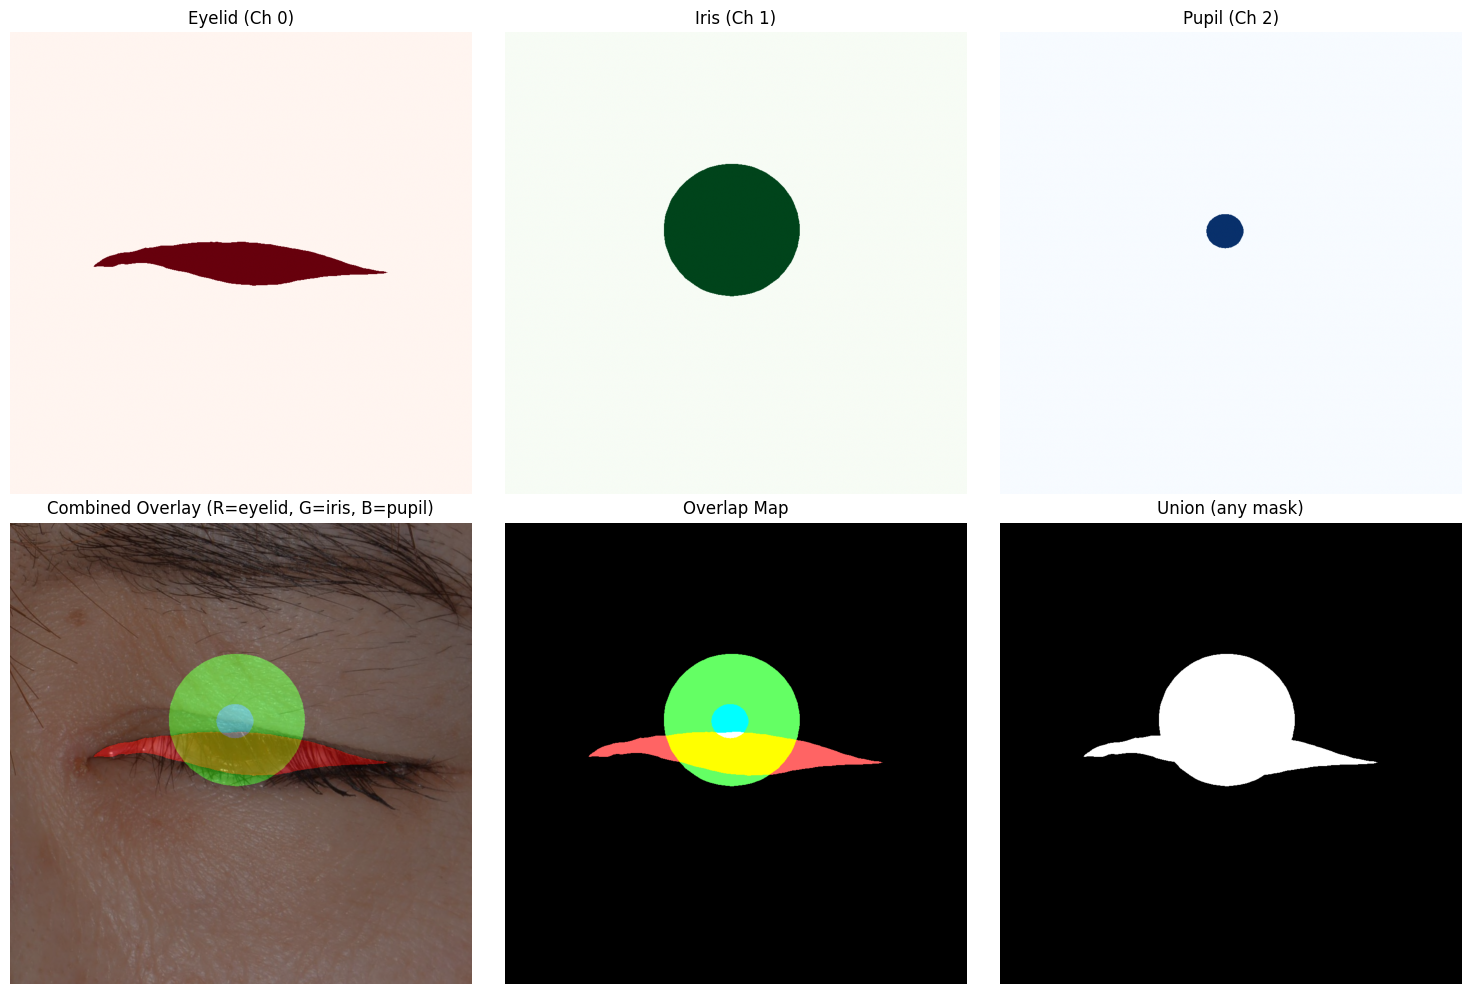

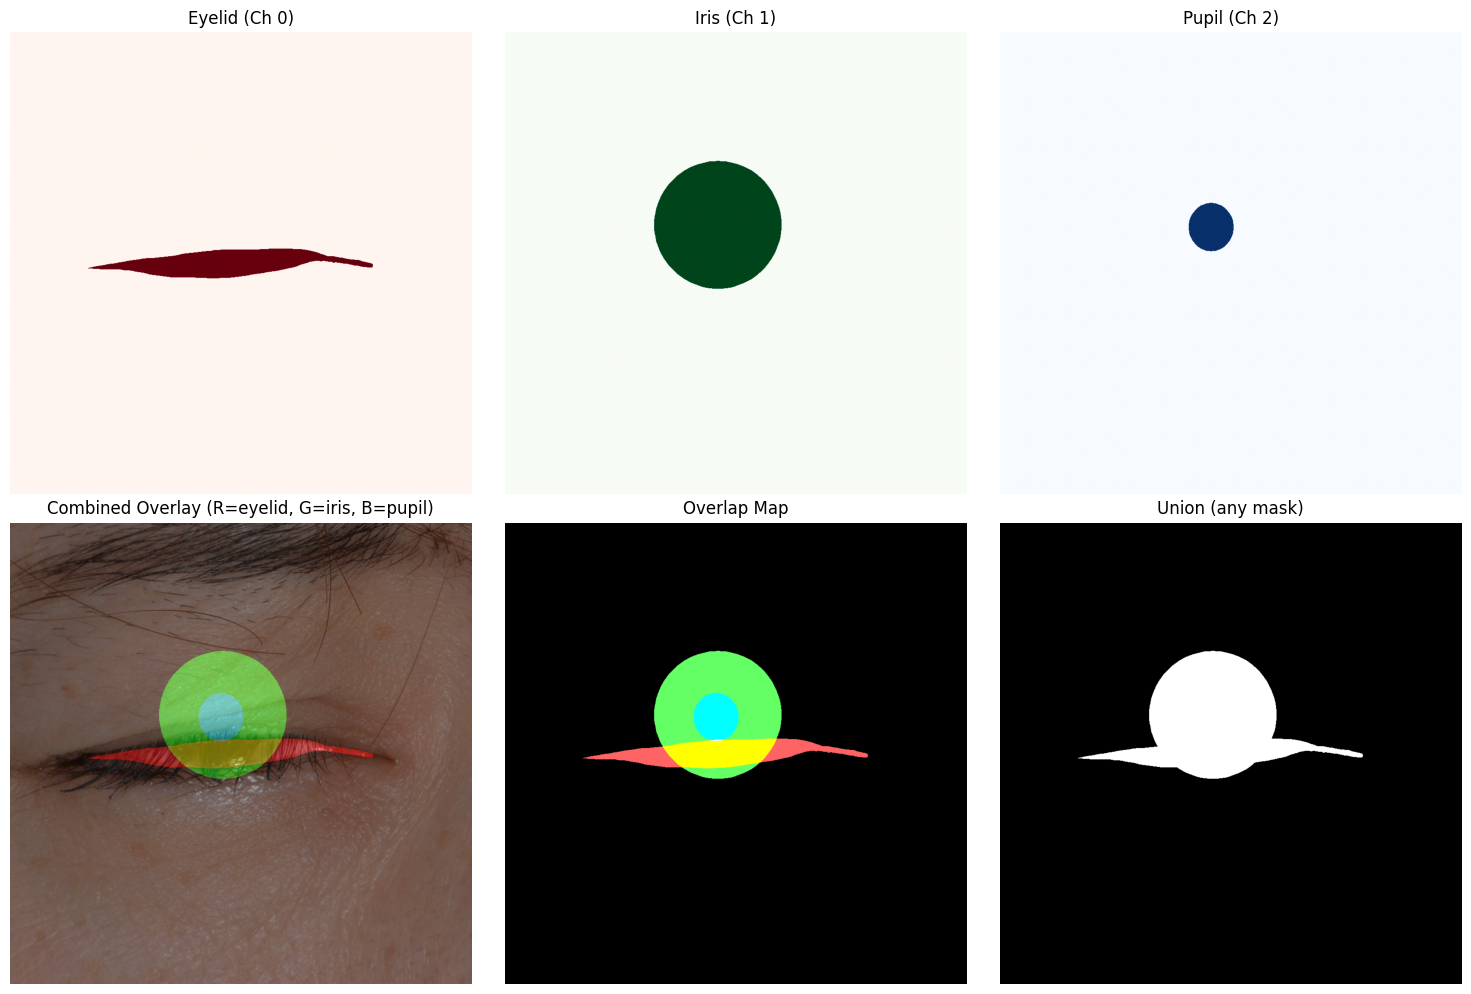

In [8]:
# ===== Cell 8: Visualize Multi-Label Masks =====
def visualize_multilabel_masks(image_name, save_path=None):
    """Visualize the 3-channel multi-label masks."""
    img = cv2.imread(str(IMAGES_DIR / image_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    masks = generate_multilabel_masks(image_name, h, w, 
                                      EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Individual masks
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f"Original: {image_name}")
    axes[0, 0].axis("off")
    
    colors = ['Reds', 'Greens', 'Blues']
    names = ['Eyelid (Ch 0)', 'Iris (Ch 1)', 'Pupil (Ch 2)']
    for c in range(3):
        axes[0, c].imshow(masks[:, :, c], cmap=colors[c], vmin=0, vmax=255)
        axes[0, c].set_title(names[c])
        axes[0, c].axis("off")
    
    # Row 2: Overlays and combined
    # Combined overlay (RGB)
    overlay = img_rgb.copy().astype(np.float32)
    alpha = 0.4
    
    # Eyelid = Red, Iris = Green, Pupil = Blue
    color_mask = np.zeros((h, w, 3), dtype=np.float32)
    color_mask[:, :, 0] = (masks[:, :, 0] > 0).astype(np.float32) * 255  # R
    color_mask[:, :, 1] = (masks[:, :, 1] > 0).astype(np.float32) * 255  # G
    color_mask[:, :, 2] = (masks[:, :, 2] > 0).astype(np.float32) * 255  # B
    
    overlay = overlay * (1 - alpha) + color_mask * alpha
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title("Combined Overlay (R=eyelid, G=iris, B=pupil)")
    axes[1, 0].axis("off")
    
    # Overlap visualization
    overlap_map = np.zeros((h, w, 3), dtype=np.uint8)
    eyelid_only = (masks[:, :, 0] > 0) & ~(masks[:, :, 1] > 0) & ~(masks[:, :, 2] > 0)
    iris_only = ~(masks[:, :, 0] > 0) & (masks[:, :, 1] > 0) & ~(masks[:, :, 2] > 0)
    eyelid_iris = (masks[:, :, 0] > 0) & (masks[:, :, 1] > 0) & ~(masks[:, :, 2] > 0)
    iris_pupil = (masks[:, :, 1] > 0) & (masks[:, :, 2] > 0)
    all_three = (masks[:, :, 0] > 0) & (masks[:, :, 1] > 0) & (masks[:, :, 2] > 0)
    
    overlap_map[eyelid_only] = [255, 100, 100]   # Light red
    overlap_map[iris_only] = [100, 255, 100]     # Light green (iris outside eyelid)
    overlap_map[eyelid_iris] = [255, 255, 0]     # Yellow (eyelid + iris)
    overlap_map[iris_pupil & ~(masks[:, :, 0] > 0)] = [0, 255, 255]  # Cyan (iris + pupil, outside eyelid)
    overlap_map[all_three] = [255, 255, 255]     # White (all three)
    
    axes[1, 1].imshow(overlap_map)
    axes[1, 1].set_title("Overlap Map")
    axes[1, 1].axis("off")
    
    # Union mask
    union = ((masks[:, :, 0] > 0) | (masks[:, :, 1] > 0) | (masks[:, :, 2] > 0)).astype(np.uint8) * 255
    axes[1, 2].imshow(union, cmap='gray')
    axes[1, 2].set_title("Union (any mask)")
    axes[1, 2].axis("off")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Visualize a few samples
for name in image_names[:2]:
    visualize_multilabel_masks(name)

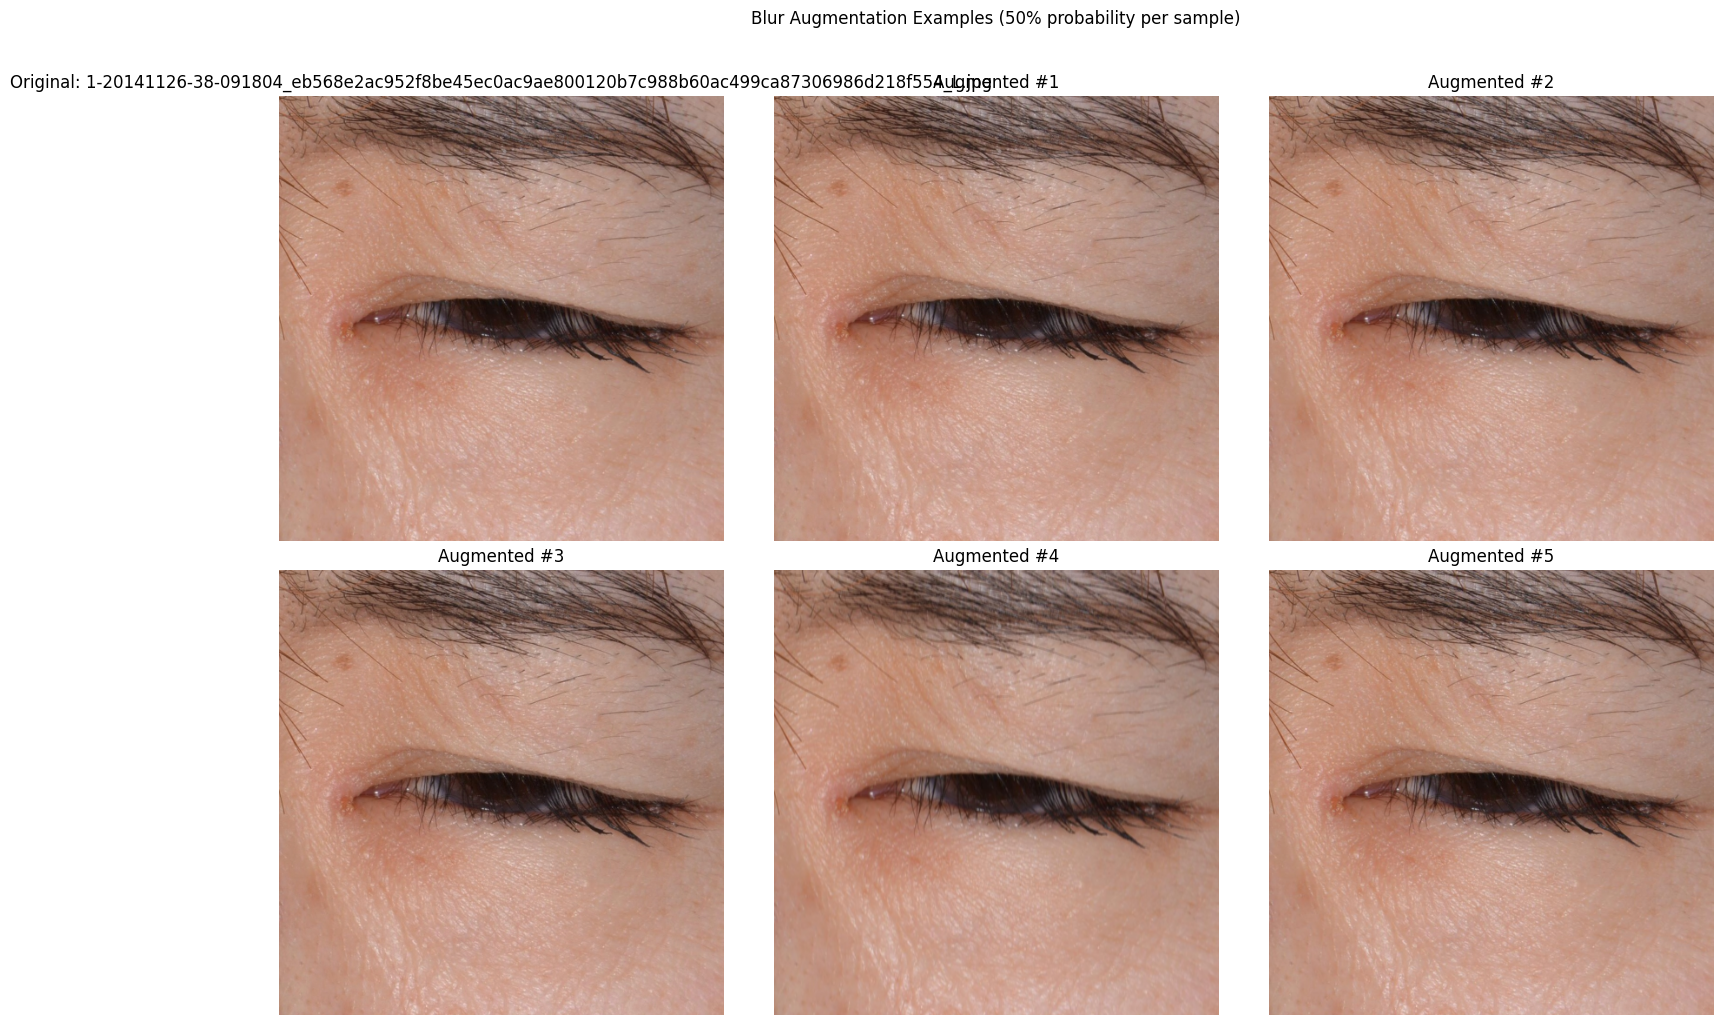

Blur augmentation examples saved to: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur\results\blur_augmentation_examples.png


In [9]:
# ===== Cell 9: Visualize Blur Augmentation Examples =====
def visualize_blur_augmentation(image_name, blur_transform, num_examples=5):
    """
    Visualize blur augmentation effects on a sample image.
    """
    img = cv2.imread(str(IMAGES_DIR / image_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original: {image_name}")
    axes[0].axis("off")
    
    # Apply blur augmentation multiple times
    for i in range(1, 6):
        augmented = blur_transform(image=img_rgb)["image"]
        axes[i].imshow(augmented)
        axes[i].set_title(f"Augmented #{i}")
        axes[i].axis("off")
    
    plt.suptitle("Blur Augmentation Examples (50% probability per sample)", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "blur_augmentation_examples.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Blur augmentation examples saved to: {RESULTS_DIR / 'blur_augmentation_examples.png'}")


# Visualize blur augmentation
visualize_blur_augmentation(image_names[0], blur_augment)

In [10]:
# ===== Cell 10: Dataset Definition with Full Augmentation =====
class EyeAmodalDatasetWithAugmentation(Dataset):
    """
    Dataset for SegFormer multi-label (amodal) segmentation.
    
    Uses Albumentations for unified augmentation pipeline:
    - RandomResizedCrop (scale augmentation) - applied to image and mask
    - Rotation - applied to image and mask
    - Blur/Low-quality augmentation - applied to image only
    """
    
    def __init__(self, image_names, images_dir, eyelid_polys_dict, ellipses_dict,
                 image_size=512, augment=False, augmentation_pipeline=None):
        self.image_names = image_names
        self.images_dir = Path(images_dir)
        self.eyelid_polys_dict = eyelid_polys_dict
        self.ellipses_dict = ellipses_dict
        self.image_size = image_size
        self.augment = augment
        
        # Albumentations augmentation pipeline
        self.augmentation_pipeline = augmentation_pipeline if augment else None
        
        # SegFormer image processor
        self.processor = SegformerImageProcessor.from_pretrained(
            SEGFORMER_MODEL_NAME,
            do_resize=False,
            do_rescale=True,
            do_normalize=True
        )
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        name = self.image_names[idx]
        
        # Load image
        img_path = self.images_dir / name
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        
        # Generate multi-label masks from XML (at original resolution, then resize)
        gt_masks = generate_multilabel_masks(
            name, orig_h, orig_w, 
            self.eyelid_polys_dict, self.ellipses_dict
        )
        gt_masks = cv2.resize(gt_masks, (self.image_size, self.image_size), 
                              interpolation=cv2.INTER_NEAREST)
        
        # Apply augmentation using Albumentations
        if self.augment and self.augmentation_pipeline is not None:
            # Albumentations expects mask as list of 2D arrays for multi-channel masks
            # We pass the 3-channel mask directly and it will be transformed together
            augmented = self.augmentation_pipeline(image=img, mask=gt_masks)
            img = augmented["image"]
            gt_masks = augmented["mask"]
        
        # SegFormer preprocessing
        inputs = self.processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)
        
        # Convert masks to tensor: (H, W, 3) -> (3, H, W), normalize to [0, 1]
        labels = torch.from_numpy(gt_masks).permute(2, 0, 1).float() / 255.0
        
        return {
            "pixel_values": pixel_values,
            "labels": labels,  # (3, H, W) float32, values in [0, 1]
            "name": name
        }


# Create datasets with augmentation pipeline
train_ds = EyeAmodalDatasetWithAugmentation(
    train_names, IMAGES_DIR, EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE,
    image_size=IMAGE_SIZE, augment=True, augmentation_pipeline=train_augment
)
val_ds = EyeAmodalDatasetWithAugmentation(
    val_names, IMAGES_DIR, EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE,
    image_size=IMAGE_SIZE, augment=False
)

print(f"Train dataset: {len(train_ds)} samples")
print(f"  Augmentation: RandomResizedCrop + Rotation + Blur")
print(f"Val dataset: {len(val_ds)} samples (no augmentation)")
print(f"Total: {len(train_ds) + len(val_ds)} samples")

# Test a sample
sample = train_ds[0]
print(f"\nSample shapes:")
print(f"  pixel_values: {sample['pixel_values'].shape}")
print(f"  labels: {sample['labels'].shape}")
print(f"  labels range: [{sample['labels'].min():.2f}, {sample['labels'].max():.2f}]")

c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Train dataset: 2426 samples
  Augmentation: RandomResizedCrop + Rotation + Blur
Val dataset: 574 samples (no augmentation)
Total: 3000 samples

Sample shapes:
  pixel_values: torch.Size([3, 512, 512])
  labels: torch.Size([3, 512, 512])
  labels range: [0.00, 1.00]


In [11]:
# ===== Cell 11: Loss Function Definition =====
class BalancedConstrainedLoss(nn.Module):
    """
    Multi-label segmentation loss with:
    1. Channel-specific Tversky loss (handles class imbalance)
    2. Channel weights (sqrt scale for size imbalance)
    3. Physical constraint (pupil ⊂ iris)
    4. Per-channel loss tracking for monitoring
    """
    
    def __init__(self, 
                 channel_weights=[1.0, 1.2, 3.0],
                 tversky_params=None,
                 constraint_weight=0.1):
        super().__init__()
        self.channel_weights = channel_weights
        self.constraint_weight = constraint_weight
        
        # Default Tversky parameters (alpha=FP weight, beta=FN weight)
        self.tversky_params = tversky_params or {
            'eyelid': {'alpha': 0.5, 'beta': 0.5},  # balanced
            'iris':   {'alpha': 0.4, 'beta': 0.6},  # slightly recall-focused
            'pupil':  {'alpha': 0.3, 'beta': 0.7},  # recall-focused
        }
        self.channel_names = ['eyelid', 'iris', 'pupil']
    
    def tversky_loss(self, pred, target, alpha, beta, smooth=1e-6):
        """
        Tversky loss for a single channel.
        TL = 1 - TP / (TP + alpha*FP + beta*FN)
        
        Args:
            pred: (B, H, W) sigmoid probabilities
            target: (B, H, W) binary targets
            alpha: weight for false positives
            beta: weight for false negatives
        """
        TP = (pred * target).sum(dim=(1, 2))
        FP = (pred * (1 - target)).sum(dim=(1, 2))
        FN = ((1 - pred) * target).sum(dim=(1, 2))
        
        tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
        return 1 - tversky.mean()
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (B, 3, H, W) raw model output
            targets: (B, 3, H, W) binary targets [0, 1]
        
        Returns:
            total_loss: scalar
            channel_losses: dict with per-channel losses
        """
        # Interpolate if sizes don't match
        if logits.shape[-2:] != targets.shape[-2:]:
            logits = F.interpolate(logits, size=targets.shape[-2:],
                                   mode='bilinear', align_corners=False)
        
        # Apply sigmoid
        probs = torch.sigmoid(logits)
        
        # Compute per-channel Tversky loss
        channel_losses = {}
        weighted_loss = 0
        weight_sum = sum(self.channel_weights)
        
        for c, name in enumerate(self.channel_names):
            params = self.tversky_params[name]
            loss = self.tversky_loss(
                probs[:, c], targets[:, c],
                params['alpha'], params['beta']
            )
            channel_losses[name] = loss.item()
            weighted_loss += self.channel_weights[c] * loss
        
        main_loss = weighted_loss / weight_sum
        
        # Physical constraint: pupil should be inside iris
        # Penalize pupil predictions outside iris predictions
        pupil_outside_iris = probs[:, 2] * (1 - probs[:, 1])
        constraint_loss = pupil_outside_iris.mean()
        
        total_loss = main_loss + self.constraint_weight * constraint_loss
        
        channel_losses['constraint'] = constraint_loss.item()
        channel_losses['total'] = total_loss.item()
        
        return total_loss, channel_losses


# Test loss function
criterion = BalancedConstrainedLoss(
    channel_weights=CHANNEL_WEIGHTS,
    tversky_params=TVERSKY_PARAMS,
    constraint_weight=CONSTRAINT_WEIGHT
)

# Dummy test
dummy_logits = torch.randn(2, 3, 128, 128)
dummy_targets = torch.randint(0, 2, (2, 3, 128, 128)).float()
loss, losses = criterion(dummy_logits, dummy_targets)
print(f"Loss function test:")
print(f"  Total loss: {loss.item():.4f}")
for name, val in losses.items():
    print(f"  {name}: {val:.4f}")

Loss function test:
  Total loss: 0.5273
  eyelid: 0.5025
  iris: 0.5029
  pupil: 0.5021
  constraint: 0.2496
  total: 0.5273


In [12]:
# ===== Cell 12: Model Definition =====
def create_segformer_model(num_labels=3):
    """
    Create SegFormer-B0 model for multi-label segmentation.
    Output: 3 channels (eyelid, iris, pupil)
    """
    model = SegformerForSemanticSegmentation.from_pretrained(
        SEGFORMER_MODEL_NAME,
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )
    return model


print(f"Model: {SEGFORMER_MODEL_NAME}")
print(f"Output channels: {NUM_CHANNELS} (multi-label with sigmoid)")

Model: nvidia/segformer-b0-finetuned-ade-512-512
Output channels: 3 (multi-label with sigmoid)


In [13]:
# ===== Cell 13: Training Functions =====
class ChannelMonitor:
    """Monitor per-channel Dice scores during training."""
    
    def __init__(self, patience=10, min_delta=0.005):
        self.best_dice = {'eyelid': 0, 'iris': 0, 'pupil': 0, 'mean': 0}
        self.patience_counter = {'eyelid': 0, 'iris': 0, 'pupil': 0}
        self.patience = patience
        self.min_delta = min_delta
    
    def update(self, dice_scores):
        """Update best scores and return warnings if any channel stagnates."""
        warnings = []
        for name in ['eyelid', 'iris', 'pupil']:
            if name not in dice_scores:
                continue
            dice = dice_scores[name]
            if dice > self.best_dice[name] + self.min_delta:
                self.best_dice[name] = dice
                self.patience_counter[name] = 0
            else:
                self.patience_counter[name] += 1
                if self.patience_counter[name] >= self.patience:
                    warnings.append(f"  [!] {name} Dice stagnant for {self.patience} epochs (best: {self.best_dice[name]:.4f})")
        
        # Track mean
        if 'mean' in dice_scores:
            self.best_dice['mean'] = max(self.best_dice['mean'], dice_scores['mean'])
        
        return warnings


def compute_dice_batch(pred, target, threshold=0.5):
    """
    Compute Dice coefficient for a batch.
    
    Args:
        pred: (B, H, W) probabilities
        target: (B, H, W) binary targets
    """
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum(dim=(1, 2))
    union = pred_binary.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    return dice.mean().item()


def train_epoch(model, loader, criterion, optimizer, scaler, device):
    """Train for one epoch with per-channel loss tracking."""
    model.train()
    total_losses = {'eyelid': 0, 'iris': 0, 'pupil': 0, 'constraint': 0, 'total': 0}
    num_batches = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            loss, channel_losses = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Accumulate losses
        for key in total_losses:
            total_losses[key] += channel_losses.get(key, 0)
        num_batches += 1
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    # Average losses
    avg_losses = {k: v / num_batches for k, v in total_losses.items()}
    return avg_losses


def validate_epoch(model, loader, criterion, device):
    """Validate with per-channel loss and Dice tracking."""
    model.eval()
    total_losses = {'eyelid': 0, 'iris': 0, 'pupil': 0, 'constraint': 0, 'total': 0}
    total_dice = {'eyelid': 0, 'iris': 0, 'pupil': 0}
    num_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            
            # Interpolate if needed
            if logits.shape[-2:] != labels.shape[-2:]:
                logits = F.interpolate(logits, size=labels.shape[-2:],
                                       mode='bilinear', align_corners=False)
            
            loss, channel_losses = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            
            # Accumulate losses
            for key in total_losses:
                total_losses[key] += channel_losses.get(key, 0)
            
            # Compute Dice per channel
            channel_names = ['eyelid', 'iris', 'pupil']
            for c, name in enumerate(channel_names):
                dice = compute_dice_batch(probs[:, c], labels[:, c])
                total_dice[name] += dice
            
            num_batches += 1
    
    # Average
    avg_losses = {k: v / num_batches for k, v in total_losses.items()}
    avg_dice = {k: v / num_batches for k, v in total_dice.items()}
    avg_dice['mean'] = sum(avg_dice.values()) / 3
    
    return avg_losses, avg_dice


print("Training functions defined.")

Training functions defined.


In [14]:
# ===== Cell 14: Run Training =====
# Create data loaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

# Create model
model = create_segformer_model(num_labels=NUM_CHANNELS).to(device)
criterion = BalancedConstrainedLoss(
    channel_weights=CHANNEL_WEIGHTS,
    tversky_params=TVERSKY_PARAMS,
    constraint_weight=CONSTRAINT_WEIGHT
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = GradScaler()
monitor = ChannelMonitor(patience=10, min_delta=0.005)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_eyelid': [], 'train_iris': [], 'train_pupil': [],
    'val_eyelid': [], 'val_iris': [], 'val_pupil': [],
    'dice_eyelid': [], 'dice_iris': [], 'dice_pupil': [], 'dice_mean': []
}

# Training loop
best_dice_mean = 0
patience_counter = 0
best_epoch = 0

print(f"\nStarting training with blur augmentation...")
print(f"Blur augmentation probability: {BLUR_AUGMENT_PROB}")
print(f"{'Epoch':>5} {'Loss':>8} {'Eyelid':>8} {'Iris':>8} {'Pupil':>8} | "
      f"{'D_Eyelid':>8} {'D_Iris':>8} {'D_Pupil':>8} {'D_Mean':>8} {'Status':>12}")
print("-" * 105)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    
    # Train
    train_losses = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    
    # Validate
    val_losses, val_dice = validate_epoch(model, val_loader, criterion, device)
    
    # Update history
    history['train_loss'].append(train_losses['total'])
    history['val_loss'].append(val_losses['total'])
    for name in ['eyelid', 'iris', 'pupil']:
        history[f'train_{name}'].append(train_losses[name])
        history[f'val_{name}'].append(val_losses[name])
        history[f'dice_{name}'].append(val_dice[name])
    history['dice_mean'].append(val_dice['mean'])
    
    # Check for improvement (based on mean Dice)
    is_best = val_dice['mean'] > best_dice_mean
    if is_best:
        best_dice_mean = val_dice['mean']
        best_epoch = epoch
        patience_counter = 0
        
        save_path = MODEL_DIR / "segformer_b0_amodal_blur_best.pth"
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_dice": val_dice,
            "val_loss": val_losses,
            "blur_prob": BLUR_AUGMENT_PROB,
        }, save_path)
        status = "* SAVED *"
    else:
        patience_counter += 1
        status = f"p={patience_counter}/{EARLY_STOP_PATIENCE}"
    
    # Print progress
    print(f"{epoch:>5} {val_losses['total']:>8.4f} "
          f"{val_losses['eyelid']:>8.4f} {val_losses['iris']:>8.4f} {val_losses['pupil']:>8.4f} | "
          f"{val_dice['eyelid']:>8.4f} {val_dice['iris']:>8.4f} {val_dice['pupil']:>8.4f} "
          f"{val_dice['mean']:>8.4f} {status:>12}")
    
    # Check for channel stagnation
    warnings = monitor.update(val_dice)
    for w in warnings:
        print(w)
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.1f} minutes")
print(f"Best model saved at epoch {best_epoch} with Mean Dice={best_dice_mean:.4f}")
print(f"Model path: {MODEL_DIR / 'segformer_b0_amodal_blur_best.pth'}")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([3]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting training with blur augmentation...
Blur augmentation probability: 0.5
Epoch     Loss   Eyelid     Iris    Pupil | D_Eyelid   D_Iris  D_Pupil   D_Mean       Status
---------------------------------------------------------------------------------------------------------


C:\Users\CorneAI\AppData\Local\Temp\ipykernel_51284\4021243052.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Training:   0%|          | 0/304 [00:00<?, ?it/s]

C:\Users\CorneAI\AppData\Local\Temp\ipykernel_51284\3241114690.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Validation:   0%|          | 0/72 [00:00<?, ?it/s]

   63   0.0774   0.0403   0.0647   0.0948 |   0.9606   0.9445   0.9082   0.9378      p=19/20
  [!] eyelid Dice stagnant for 10 epochs (best: 0.9586)
  [!] iris Dice stagnant for 10 epochs (best: 0.9426)
  [!] pupil Dice stagnant for 10 epochs (best: 0.9111)


Training:   0%|          | 0/304 [00:00<?, ?it/s]

Validation:   0%|          | 0/72 [00:00<?, ?it/s]

   64   0.0751   0.0403   0.0654   0.0906 |   0.9606   0.9334   0.9027   0.9322      p=20/20
  [!] eyelid Dice stagnant for 10 epochs (best: 0.9586)
  [!] iris Dice stagnant for 10 epochs (best: 0.9426)
  [!] pupil Dice stagnant for 10 epochs (best: 0.9111)

Early stopping at epoch 64

Training completed in 127.0 minutes
Best model saved at epoch 44 with Mean Dice=0.9381
Model path: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur\models\segformer_b0_amodal_blur_best.pth


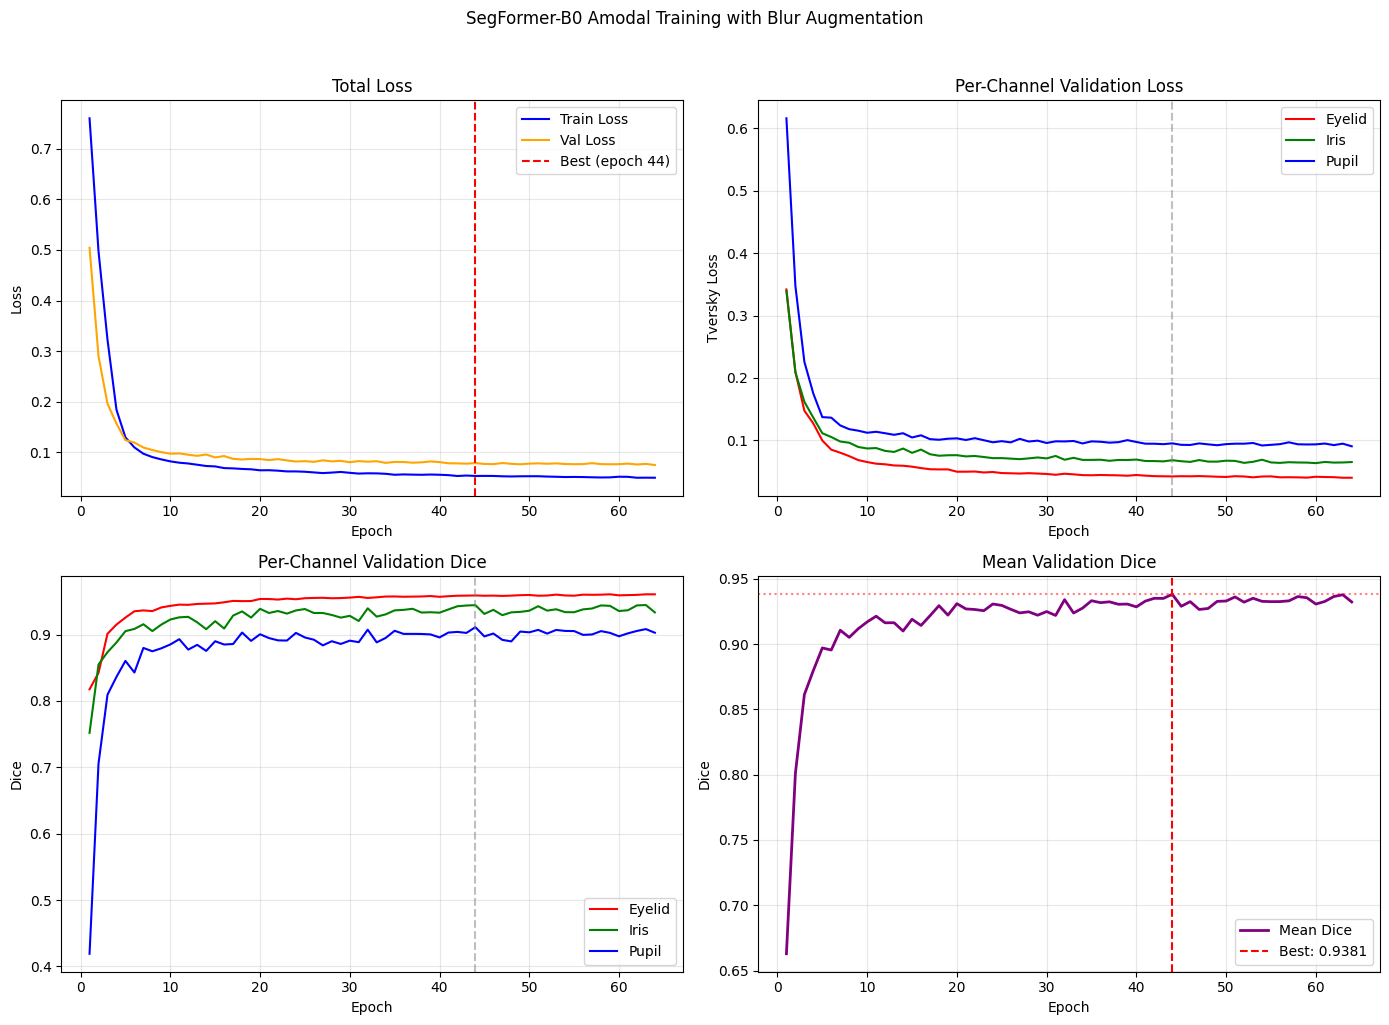

Training plots saved to: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur\results\training_progress.png


In [15]:
# ===== Cell 15: Training Plots =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Plot 1: Total Loss
ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
ax.plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Total Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Per-channel Val Loss
ax = axes[0, 1]
colors = {'eyelid': 'red', 'iris': 'green', 'pupil': 'blue'}
for name in ['eyelid', 'iris', 'pupil']:
    ax.plot(epochs_range, history[f'val_{name}'], label=f'{name.capitalize()}', color=colors[name])
ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Tversky Loss')
ax.set_title('Per-Channel Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Per-channel Dice
ax = axes[1, 0]
for name in ['eyelid', 'iris', 'pupil']:
    ax.plot(epochs_range, history[f'dice_{name}'], label=f'{name.capitalize()}', color=colors[name])
ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice')
ax.set_title('Per-Channel Validation Dice')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Mean Dice
ax = axes[1, 1]
ax.plot(epochs_range, history['dice_mean'], label='Mean Dice', color='purple', linewidth=2)
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best: {best_dice_mean:.4f}')
ax.axhline(y=best_dice_mean, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice')
ax.set_title('Mean Validation Dice')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('SegFormer-B0 Amodal Training with Blur Augmentation', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training plots saved to: {RESULTS_DIR / 'training_progress.png'}")

---
# Inference & Evaluation

In [16]:
# ===== Cell 16: Load Best Model =====
model_path = MODEL_DIR / "segformer_b0_amodal_blur_best.pth"
if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

model = create_segformer_model(num_labels=NUM_CHANNELS).to(device)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

print(f"Loaded model from: {model_path}")
print(f"  - Epoch: {checkpoint['epoch']}")
print(f"  - Val Dice: {checkpoint['val_dice']}")
print(f"  - Blur prob: {checkpoint.get('blur_prob', 'N/A')}")

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([3]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded model from: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur\models\segformer_b0_amodal_blur_best.pth
  - Epoch: 44
  - Val Dice: {'eyelid': 0.9589146715071466, 'iris': 0.9443045597937372, 'pupil': 0.9110995646980073, 'mean': 0.9381062653329636}
  - Blur prob: 0.5


In [17]:
# ===== Cell 17: Inference Utilities =====
def predict_amodal(model, img_path, device, image_size=512, threshold=0.5):
    """
    Run amodal inference on a single image.
    
    Returns:
        masks: dict with 'eyelid', 'iris', 'pupil' binary masks (0 or 255)
        probs: dict with probability maps
    """
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    
    processor = SegformerImageProcessor.from_pretrained(
        SEGFORMER_MODEL_NAME, do_resize=False, do_rescale=True, do_normalize=True
    )
    inputs = processor(images=img_rgb, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        
        if logits.shape[-2:] != (image_size, image_size):
            logits = F.interpolate(
                logits, size=(image_size, image_size),
                mode='bilinear', align_corners=False
            )
        
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
    
    channel_names = ['eyelid', 'iris', 'pupil']
    masks = {}
    probs_dict = {}
    
    for c, name in enumerate(channel_names):
        probs_dict[name] = probs[c]
        masks[name] = ((probs[c] > threshold) * 255).astype(np.uint8)
    
    return masks, probs_dict


def fit_ellipse_mask(binary_mask):
    """Fit ellipse to binary mask for smoother output."""
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return binary_mask.copy()
    
    largest = max(contours, key=cv2.contourArea)
    if len(largest) < 5:
        return binary_mask.copy()
    
    ellipse = cv2.fitEllipse(largest)
    result = np.zeros_like(binary_mask)
    cv2.ellipse(result, ellipse, 255, -1)
    return result


def make_overlay(img_rgb, eyelid, iris, pupil, alpha=0.4):
    """Create overlay: eyelid=RED, iris=GREEN, pupil=BLUE"""
    h, w = img_rgb.shape[:2]
    color = np.zeros((h, w, 3), dtype=np.float32)
    color[eyelid > 0, 0] = 255
    color[iris > 0, 1] = 255
    color[pupil > 0, 2] = 255
    overlay = img_rgb.astype(np.float32) * (1 - alpha) + color * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)


print("Inference utilities defined.")

Inference utilities defined.


Running inference visualization...


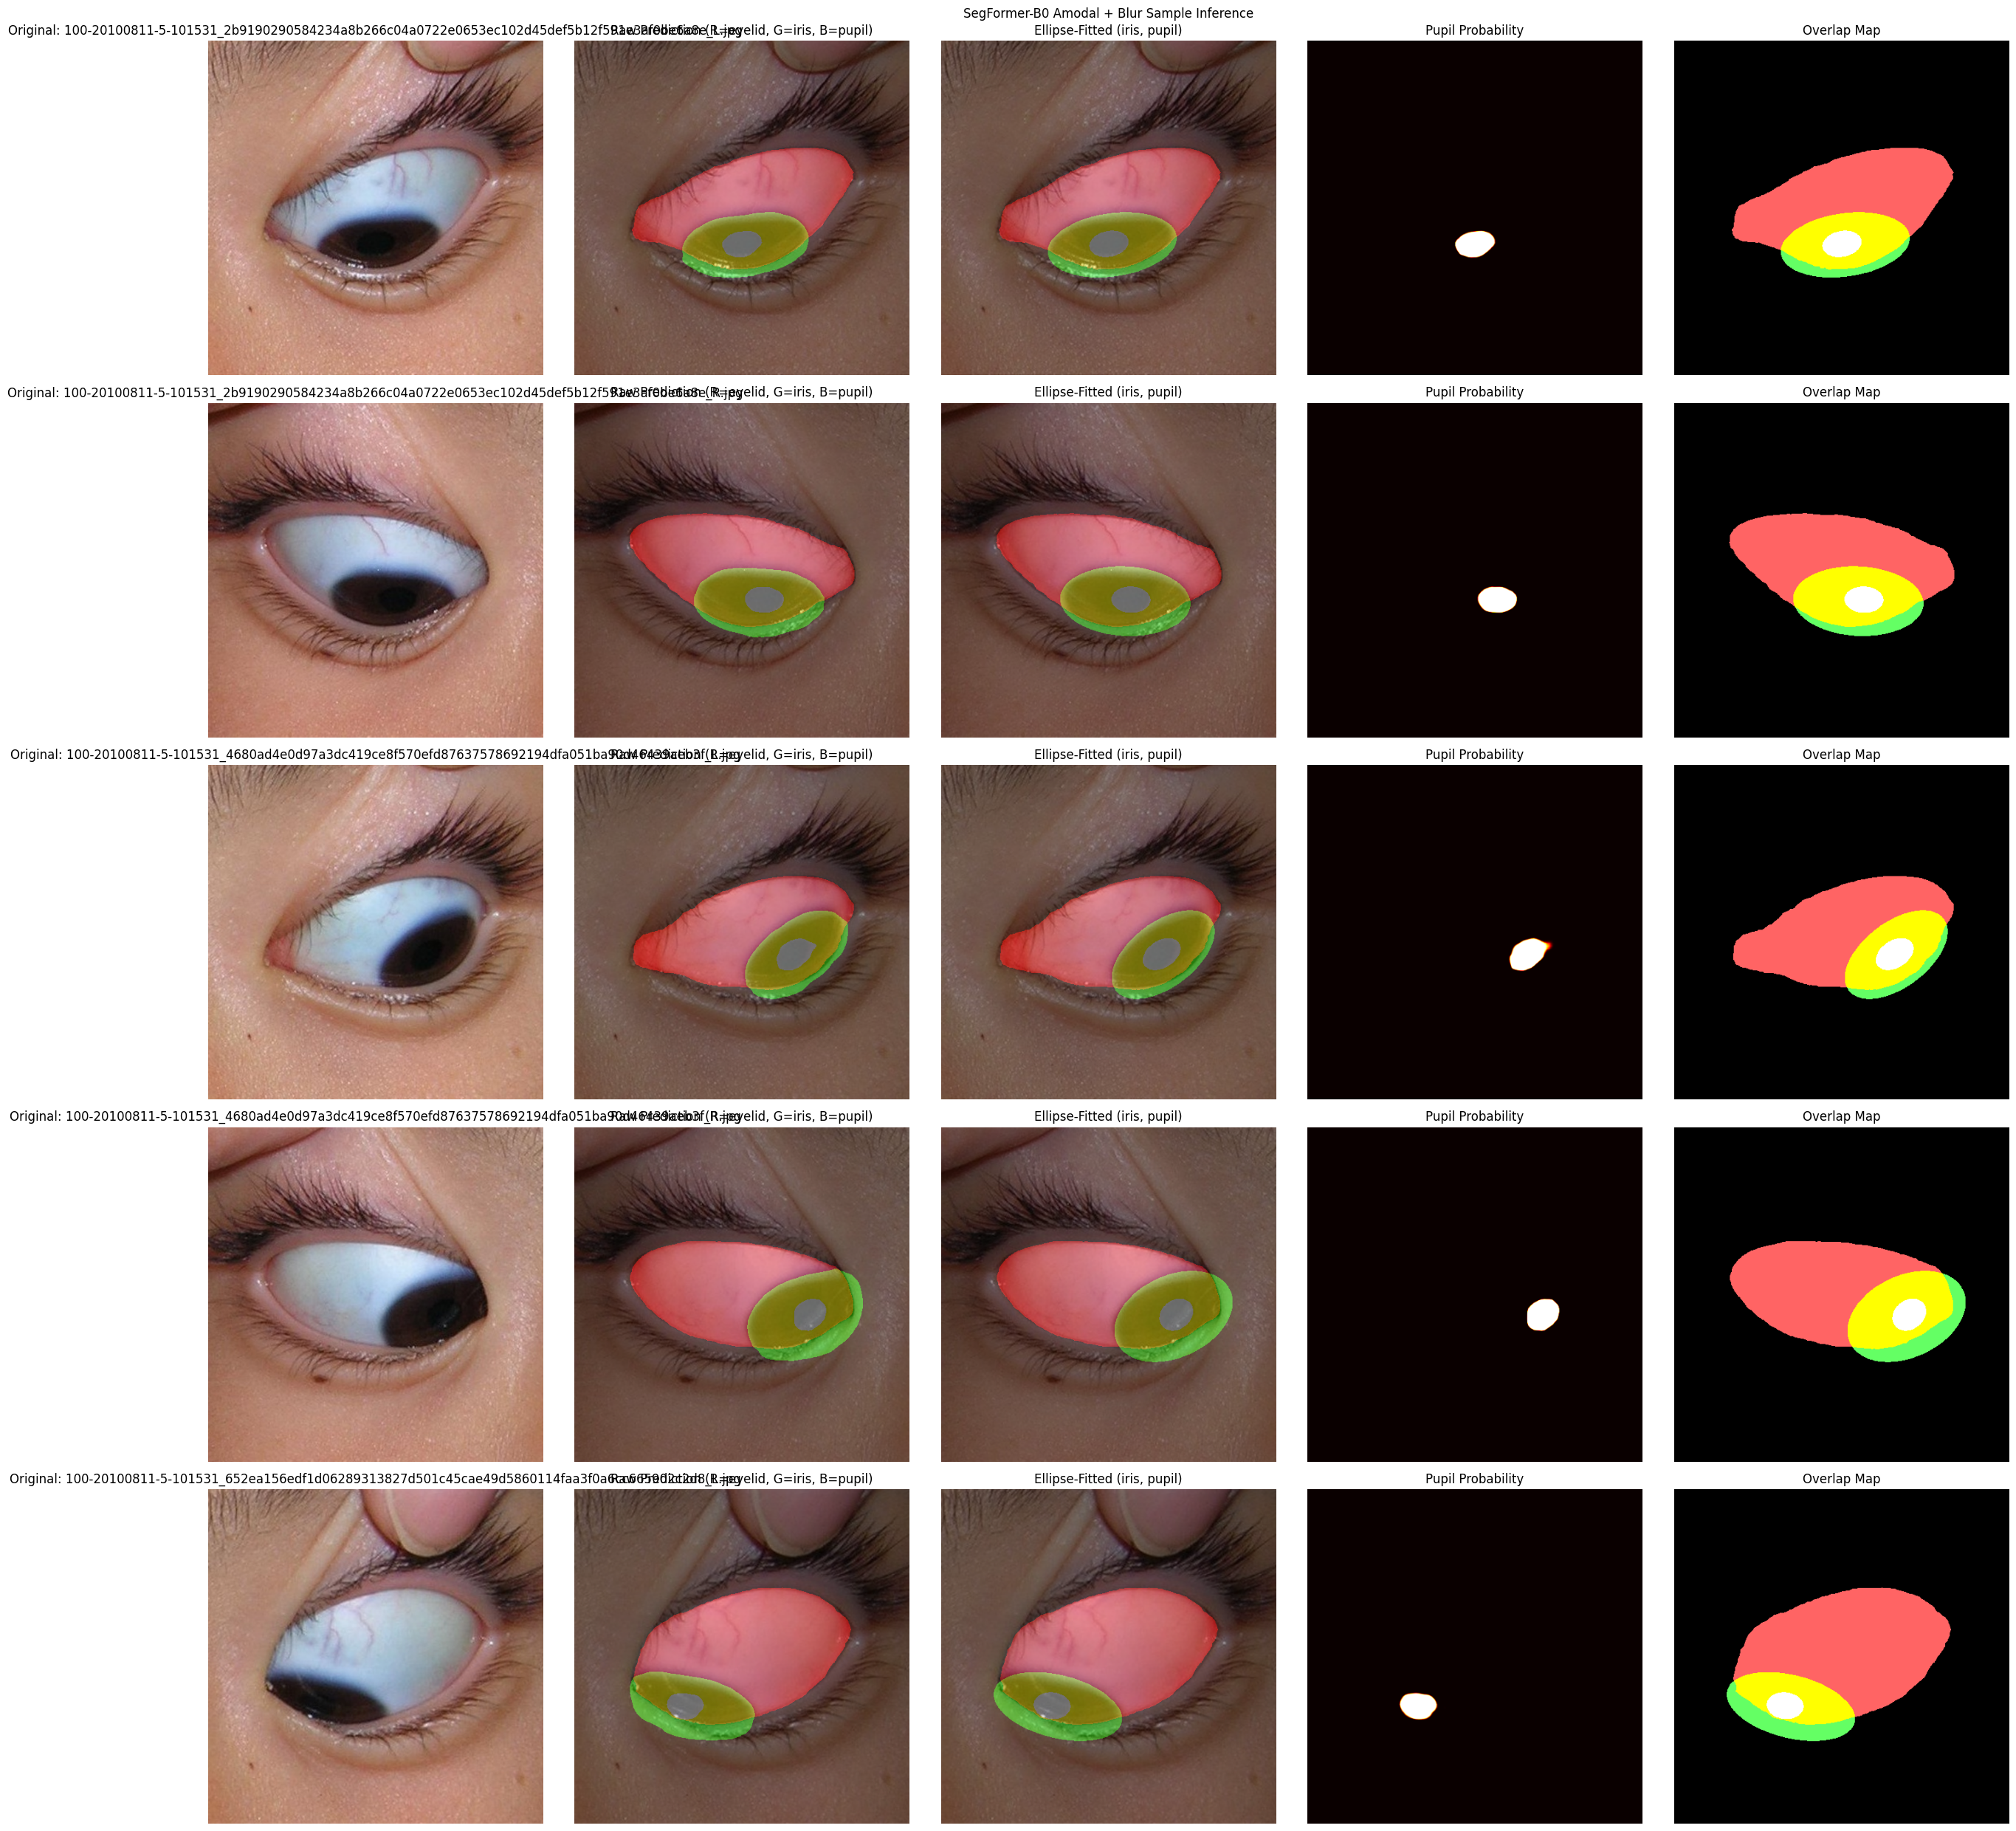

Visualization saved to: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur\results\inference_visualization.png


In [23]:
# ===== Cell 18: Visualization =====
def visualize_amodal_results(model, sample_names, title_prefix="SegFormer-B0 Amodal + Blur", num_samples=5):
    """Visualize amodal inference results."""
    samples = sample_names[:num_samples]
    n = len(samples)
    
    fig, axes = plt.subplots(n, 5, figsize=(25, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for row, name in enumerate(samples):
        img_path = IMAGES_DIR / name
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE)), cv2.COLOR_BGR2RGB)
        
        masks, probs = predict_amodal(model, img_path, device, IMAGE_SIZE)
        
        # Raw predictions
        overlay_raw = make_overlay(img_rgb, masks['eyelid'], masks['iris'], masks['pupil'])
        
        # Ellipse-fitted predictions (for iris and pupil)
        iris_fit = fit_ellipse_mask(masks['iris'])
        pupil_fit = fit_ellipse_mask(masks['pupil'])
        overlay_fit = make_overlay(img_rgb, masks['eyelid'], iris_fit, pupil_fit)
        
        # Column 0: Original
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"Original: {name}")
        axes[row, 0].axis("off")
        
        # Column 1: Raw overlay
        axes[row, 1].imshow(overlay_raw)
        axes[row, 1].set_title("Raw Prediction (R=eyelid, G=iris, B=pupil)")
        axes[row, 1].axis("off")
        
        # Column 2: Ellipse-fitted overlay
        axes[row, 2].imshow(overlay_fit)
        axes[row, 2].set_title("Ellipse-Fitted (iris, pupil)")
        axes[row, 2].axis("off")
        
        # Column 3: Probability heatmap (pupil - hardest to predict)
        axes[row, 3].imshow(probs['pupil'], cmap='hot', vmin=0, vmax=1)
        axes[row, 3].set_title("Pupil Probability")
        axes[row, 3].axis("off")
        
        # Column 4: Overlap check
        h, w = IMAGE_SIZE, IMAGE_SIZE
        overlap_map = np.zeros((h, w, 3), dtype=np.uint8)
        eyelid_m = masks['eyelid'] > 0
        iris_m = iris_fit > 0
        pupil_m = pupil_fit > 0
        
        # Color by overlap level
        overlap_map[eyelid_m & ~iris_m & ~pupil_m] = [255, 100, 100]   # Eyelid only
        overlap_map[~eyelid_m & iris_m & ~pupil_m] = [100, 255, 100]   # Iris only (occ)
        overlap_map[eyelid_m & iris_m & ~pupil_m] = [255, 255, 0]      # Eyelid + Iris
        overlap_map[eyelid_m & iris_m & pupil_m] = [255, 255, 255]     # All three
        overlap_map[~eyelid_m & iris_m & pupil_m] = [0, 255, 255]      # Iris + Pupil (occ)
        
        axes[row, 4].imshow(overlap_map)
        axes[row, 4].set_title("Overlap Map")
        axes[row, 4].axis("off")
    
    plt.suptitle(f"{title_prefix} Sample Inference", y=0.99)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "inference_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Visualization saved to: {RESULTS_DIR / 'inference_visualization.png'}")


print("Running inference visualization...")
visualize_amodal_results(model, val_names, title_prefix="SegFormer-B0 Amodal + Blur", num_samples=5)

In [19]:
# ===== Cell 19: DICE Evaluation =====
from scipy import stats

def compute_dice(pred_mask, gt_mask):
    """Compute Dice coefficient."""
    pred = (pred_mask > 0).astype(np.float32)
    gt = (gt_mask > 0).astype(np.float32)
    
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    
    return (2 * intersection) / union


def evaluate_amodal_on_dataset(model, image_names, device):
    """Evaluate Dice scores on dataset."""
    results = []
    
    for name in tqdm(image_names, desc="Evaluating DICE"):
        img_path = IMAGES_DIR / name
        
        # Prediction
        pred_masks, _ = predict_amodal(model, img_path, device, IMAGE_SIZE)
        
        # Ground truth
        img = cv2.imread(str(img_path))
        orig_h, orig_w = img.shape[:2]
        gt_masks = generate_multilabel_masks(
            name, orig_h, orig_w, 
            EYELID_POLYS_BY_IMAGE, ELLIPSES_BY_IMAGE
        )
        gt_masks = cv2.resize(gt_masks, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        
        # Raw predictions
        dice_eyelid = compute_dice(pred_masks['eyelid'], gt_masks[:, :, 0])
        dice_iris_raw = compute_dice(pred_masks['iris'], gt_masks[:, :, 1])
        dice_pupil_raw = compute_dice(pred_masks['pupil'], gt_masks[:, :, 2])
        
        # Ellipse-fitted predictions
        iris_fit = fit_ellipse_mask(pred_masks['iris'])
        pupil_fit = fit_ellipse_mask(pred_masks['pupil'])
        dice_iris_fit = compute_dice(iris_fit, gt_masks[:, :, 1])
        dice_pupil_fit = compute_dice(pupil_fit, gt_masks[:, :, 2])
        
        result = {
            "image": name,
            "dice_eyelid": dice_eyelid,
            "dice_iris_raw": dice_iris_raw,
            "dice_pupil_raw": dice_pupil_raw,
            "dice_iris_fit": dice_iris_fit,
            "dice_pupil_fit": dice_pupil_fit,
            "dice_mean_raw": (dice_eyelid + dice_iris_raw + dice_pupil_raw) / 3,
            "dice_mean_fit": (dice_eyelid + dice_iris_fit + dice_pupil_fit) / 3,
        }
        results.append(result)
    
    results_df = pd.DataFrame(results)
    
    summary = {
        "dice_eyelid": results_df["dice_eyelid"].mean(),
        "dice_eyelid_std": results_df["dice_eyelid"].std(),
        "dice_iris_raw": results_df["dice_iris_raw"].mean(),
        "dice_iris_raw_std": results_df["dice_iris_raw"].std(),
        "dice_pupil_raw": results_df["dice_pupil_raw"].mean(),
        "dice_pupil_raw_std": results_df["dice_pupil_raw"].std(),
        "dice_iris_fit": results_df["dice_iris_fit"].mean(),
        "dice_iris_fit_std": results_df["dice_iris_fit"].std(),
        "dice_pupil_fit": results_df["dice_pupil_fit"].mean(),
        "dice_pupil_fit_std": results_df["dice_pupil_fit"].std(),
        "dice_mean_raw": results_df["dice_mean_raw"].mean(),
        "dice_mean_raw_std": results_df["dice_mean_raw"].std(),
        "dice_mean_fit": results_df["dice_mean_fit"].mean(),
        "dice_mean_fit_std": results_df["dice_mean_fit"].std(),
    }
    
    return results_df, summary


print("Evaluating DICE on validation set...")
results_df, summary = evaluate_amodal_on_dataset(model, val_names, device)

results_df.to_csv(RESULTS_DIR / "dice_evaluation.csv", index=False)

print("\n" + "="*60)
print("DICE Evaluation Summary (Validation Set)")
print("="*60)
print(f"\nRaw Predictions:")
print(f"  Eyelid:  {summary['dice_eyelid']:.4f} +/- {summary['dice_eyelid_std']:.4f}")
print(f"  Iris:    {summary['dice_iris_raw']:.4f} +/- {summary['dice_iris_raw_std']:.4f}")
print(f"  Pupil:   {summary['dice_pupil_raw']:.4f} +/- {summary['dice_pupil_raw_std']:.4f}")
print(f"  Mean:    {summary['dice_mean_raw']:.4f} +/- {summary['dice_mean_raw_std']:.4f}")

print(f"\nEllipse-Fitted (Iris & Pupil):")
print(f"  Eyelid:  {summary['dice_eyelid']:.4f} +/- {summary['dice_eyelid_std']:.4f}")
print(f"  Iris:    {summary['dice_iris_fit']:.4f} +/- {summary['dice_iris_fit_std']:.4f}")
print(f"  Pupil:   {summary['dice_pupil_fit']:.4f} +/- {summary['dice_pupil_fit_std']:.4f}")
print(f"  Mean:    {summary['dice_mean_fit']:.4f} +/- {summary['dice_mean_fit_std']:.4f}")

print(f"\nResults saved to: {RESULTS_DIR / 'dice_evaluation.csv'}")

Evaluating DICE on validation set...


Evaluating DICE:   0%|          | 0/574 [00:00<?, ?it/s]


DICE Evaluation Summary (Validation Set)

Raw Predictions:
  Eyelid:  0.9589 +/- 0.1210
  Iris:    0.9443 +/- 0.1041
  Pupil:   0.9110 +/- 0.1452
  Mean:    0.9381 +/- 0.0891

Ellipse-Fitted (Iris & Pupil):
  Eyelid:  0.9589 +/- 0.1210
  Iris:    0.9458 +/- 0.1049
  Pupil:   0.9115 +/- 0.1453
  Mean:    0.9387 +/- 0.0892

Results saved to: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_SegFormerB0_Amodal_Blur\results\dice_evaluation.csv


In [20]:
# ===== Cell 20: Final Summary =====
print("\n" + "="*60)
print("SegFormer-B0 Amodal Training with Full Augmentation Complete")
print("="*60)
print(f"\nModel: {SEGFORMER_MODEL_NAME}")
print(f"Approach: Multi-label (3 independent binary masks)")
print(f"Dataset: {len(train_names)} train / {len(val_names)} val images")
print(f"Total: {len(train_names) + len(val_names)} images")
print(f"\nAugmentation Pipeline:")
print(f"  1. RandomResizedCrop (p={RANDOM_RESIZED_CROP_PROB}):")
print(f"     - Scale: {RANDOM_RESIZED_CROP_SCALE} (crop 80%-100% of image)")
print(f"     - Ratio: {RANDOM_RESIZED_CROP_RATIO}")
print(f"  2. Random Rotation:")
print(f"     - Limit: +/- {ROTATION_DEGREE} degrees")
print(f"  3. Blur/Low-quality augmentation (p={BLUR_AUGMENT_PROB}):")
print(f"     - Blur (kernel 3-7)")
print(f"     - MotionBlur (kernel 3-15)")
print(f"     - GaussianBlur (kernel 3-7)")
print(f"     - ImageCompression (quality 30-80)")
print(f"     - Downscale (scale 0.25-0.5)")
print(f"\nLoss Function:")
print(f"  - Tversky Loss (channel-specific alpha/beta)")
print(f"  - Channel weights: {CHANNEL_WEIGHTS}")
print(f"  - Physical constraint: pupil ⊂ iris (weight={CONSTRAINT_WEIGHT})")
print(f"\nBest epoch: {best_epoch}")
print(f"Best Mean Dice: {best_dice_mean:.4f}")
print(f"\nPer-Channel Results (Ellipse-Fitted):")
print(f"  Eyelid: {summary['dice_eyelid']:.4f} +/- {summary['dice_eyelid_std']:.4f}")
print(f"  Iris:   {summary['dice_iris_fit']:.4f} +/- {summary['dice_iris_fit_std']:.4f}")
print(f"  Pupil:  {summary['dice_pupil_fit']:.4f} +/- {summary['dice_pupil_fit_std']:.4f}")
print(f"  Mean:   {summary['dice_mean_fit']:.4f} +/- {summary['dice_mean_fit_std']:.4f}")
print(f"\nOutputs:")
print(f"  Model: {MODEL_DIR / 'segformer_b0_amodal_blur_best.pth'}")
print(f"  Training plots: {RESULTS_DIR / 'training_progress.png'}")
print(f"  Blur examples: {RESULTS_DIR / 'blur_augmentation_examples.png'}")
print(f"  Visualization: {RESULTS_DIR / 'inference_visualization.png'}")
print(f"  DICE results: {RESULTS_DIR / 'dice_evaluation.csv'}")


SegFormer-B0 Amodal Training with Full Augmentation Complete

Model: nvidia/segformer-b0-finetuned-ade-512-512
Approach: Multi-label (3 independent binary masks)
Dataset: 2426 train / 574 val images
Total: 3000 images

Augmentation Pipeline:
  1. RandomResizedCrop (p=0.5):
     - Scale: (0.8, 1.0) (crop 80%-100% of image)
     - Ratio: (0.9, 1.1)
  2. Random Rotation:
     - Limit: +/- 180 degrees
  3. Blur/Low-quality augmentation (p=0.5):
     - Blur (kernel 3-7)
     - MotionBlur (kernel 3-15)
     - GaussianBlur (kernel 3-7)
     - ImageCompression (quality 30-80)
     - Downscale (scale 0.25-0.5)

Loss Function:
  - Tversky Loss (channel-specific alpha/beta)
  - Channel weights: [1.0, 1.2, 3.0]
  - Physical constraint: pupil ⊂ iris (weight=0.1)

Best epoch: 44
Best Mean Dice: 0.9381

Per-Channel Results (Ellipse-Fitted):
  Eyelid: 0.9589 +/- 0.1210
  Iris:   0.9458 +/- 0.1049
  Pupil:  0.9115 +/- 0.1453
  Mean:   0.9387 +/- 0.0892

Outputs:
  Model: C:\Users\CorneAI\Eyelid_Iris_p